# Explainable AI (XAI): Why do we need explanations?

Modern deep neural networks – especially **CNNs and Transformers** – achieve extremely high accuracy on tasks like image classification, speech recognition, and natural language understanding.  
However, they are often treated as **black boxes**:

- We see the **input** (image, text, etc.)  
- We see the **output** (class label, probability)  
- We **do not** see *why* the model made that prediction  

For many real-world applications, this is not enough. We may need to answer questions like:

- *Which parts of the image caused the model to predict “pneumonia”?*  
- *Is the model looking at the tumor or an unrelated artifact?*  
- *Can a domain expert verify that the model’s reasoning is sensible?*  

This motivates the field of **Explainable AI (XAI)**.

---

## What is XAI?

**Explainable AI (XAI)** refers to a family of methods designed to interpret and understand model predictions.  
These methods aim to:

- Provide **human-interpretable explanations** for model decisions  
- Identify **important features** that influenced a prediction  
- Reveal **spurious correlations** the model might rely on  
- Improve **trust**, **transparency**, and **debuggability** of AI systems  

Different XAI methods answer different interpretability questions:

- *Where is the model “looking”?* → **CAM, Grad-CAM, Grad-CAM++**  
- *Which local changes matter the most?* → **Occlusion, LIME**  
- *How much did each feature contribute, fairly?* → **SHAP**  
- *How does output change from a baseline to the input?* → **Integrated Gradients**

---

## A motivating example

Suppose we give an ImageNet classifier this image:

> 🐶 A dog sitting on a grassy field

The model predicts:



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [2]:
!pip install captum shap lime scikit-image grad-cam --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 20.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 123.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Captum for attributions (Integrated Gradients, Occlusion, GuidedBackprop)
from captum.attr import IntegratedGradients, Occlusion, GuidedBackprop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [5]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = model.eval().to(device)

# Preprocessing transform for ImageNet models
preprocess = weights.transforms()
imagenet_labels = weights.meta["categories"]


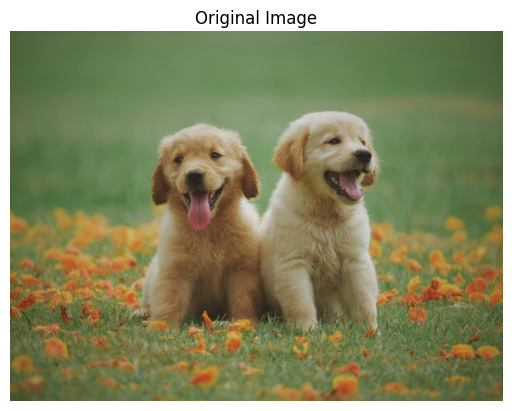

In [6]:
# Example image: a dog (change if you like)
IMAGE_URL = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"

response = requests.get(IMAGE_URL)
img_pil = Image.open(BytesIO(response.content)).convert("RGB")
plt.imshow(img_pil)
plt.axis("off")
plt.title("Original Image")
plt.show()


In [7]:
def prepare_image(img_pil):
    # preprocess returns a tensor [C,H,W], we need [1,C,H,W]
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    return input_tensor

def predict(input_tensor):
    with torch.no_grad():
        logits = model(input_tensor)
        probs = logits.softmax(dim=1)
    return probs, logits

input_tensor = prepare_image(img_pil)
probs, logits = predict(input_tensor)
top_prob, top_idx = probs.max(dim=1)
pred_label = imagenet_labels[top_idx.item()]

print(f"Top prediction: {pred_label} (prob={top_prob.item():.3f})")


Top prediction: golden retriever (prob=0.543)


---

## Occlusion Sensitivity

### What is Occlusion?

**Occlusion sensitivity** is one of the simplest and most intuitive XAI methods:

> *“If I hide this part of the image, does the model’s confidence in the class go down?”*

The idea is:

1. Take the original image.
2. Slide a small **patch (window)** over the image.
3. For each patch location:
   - Replace that region with a baseline value (e.g., gray or zero).
   - Run the model again and measure how the **target class probability** changes.
4. If hiding a region causes a *large drop* in the target probability, that region is considered **important** for the prediction.

The result is a **heatmap** over the image, where high-intensity areas indicate regions that strongly support the class.

---

### Intuition

- Think of the image as a set of “visual features”.  
- Occlusion answers:  
  > “How much does the prediction change when I remove this local feature?”  
- It is completely **model-agnostic**:
  - No gradients needed  
  - Works with *any* classifier (deep networks, random forests, etc.)
- It is conceptually similar to feature ablation in tabular data.

---

### Pros and Cons

**Pros:**
- Very **intuitive and visual**.  
- **Model-agnostic**: works with any black-box model.  
- Easy to explain to non-technical audiences.

**Cons:**
- **Computationally expensive**:
  - Requires many forward passes (one per patch position).  
- Resolution–cost tradeoff:
  - Small patch → more detailed heatmap but more computation.  
  - Large patch → coarser heatmap but faster.  
- Only shows local sensitivity to *removal* of regions; it does not capture more subtle interactions between distant regions.

---

### In this notebook

We will:

1. Use a pretrained **ResNet-50** model.  
2. Slide a patch over the input image using **Captum’s `Occlusion`**.  
3. Visualize the resulting importance heatmap over the original image.  

This will give us a first, very intuitive explanation of where the network is “looking” when it makes its prediction.


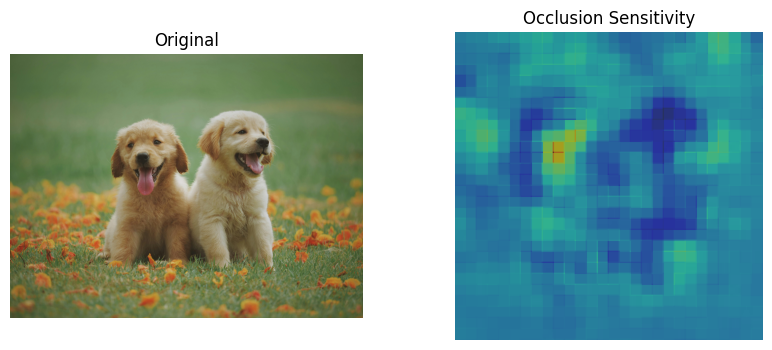

In [10]:
occlusion = Occlusion(model)

# Convert image to tensor with gradient
input_tensor.requires_grad = False

# We’ll focus on the top predicted class
target = top_idx.item()

# Occlusion parameters
# sliding window size: 15x15, stride: 8
attributions_occ = occlusion.attribute(
    input_tensor,
    strides=(1, 8, 8),
    target=target,
    sliding_window_shapes=(1, 15, 15),
    baselines=0
)

# Aggregate over channels (sum)
attr_occ = attributions_occ.squeeze().detach().cpu().numpy()
attr_occ = attr_occ.sum(axis=0)

# Normalize for visualization
attr_occ_norm = (attr_occ - attr_occ.min()) / (attr_occ.max() - attr_occ.min() + 1e-8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_pil)
plt.imshow(attr_occ_norm, cmap="jet", alpha=0.5)
plt.title("Occlusion Sensitivity")
plt.axis("off")
plt.show()


---

## Integrated Gradients (IG)

### What are Integrated Gradients?

**Integrated Gradients (IG)** is a gradient-based attribution method designed to explain a model’s prediction by attributing importance scores to each input feature (e.g., each pixel in an image).

The key idea:

> Instead of using a single gradient at the input (which can be noisy or zero due to saturation), **integrate gradients** along a smooth path from a **baseline** input to the actual input.

- **Baseline**: a reference input that represents “absence of signal”  
  - For images: often a black image (all zeros) or blurred image  
- **Path**: a straight line in input space from baseline \( x' \) to input \( x \)

---

### Intuition

Plain saliency (just using \( \frac{\partial F(x)}{\partial x} \)) can fail when:

- The network is **saturated** (gradients close to zero even for important features)
- Gradients are noisy or highly local

**Integrated Gradients** addresses this by:

1. Starting at the baseline \( x' \) (no signal).
2. Gradually moving towards the real input \( x \) in small steps.
3. At each point along this path, compute the gradient of the output w.r.t. input.
4. Accumulate (integrate) these gradients along the path.

This captures **how the prediction changes** as features “turn on” from baseline to input, giving a more robust attribution.

---

### Formal definition

Let:
- \( $F(x)$ \) be the model’s output for the target class (a scalar).
- \( x \) be the input.
- \( x' \) be the baseline.
- \( $x_i$ \) be the \(i\)-th input feature (pixel, channel, etc.).

The **Integrated Gradient** for feature \( i \) is:

\[
$\text{IG}_i(x) = (x_i - x'_i) \cdot \int_{\alpha=0}^{1}
\frac{\partial F\big(x' + \alpha (x - x')\big)}{\partial x_i} \, d\alpha$
\]

In practice, we approximate the integral with a Riemann sum using \( m \) steps:

\[
$\text{IG}_i(x) \approx (x_i - x'_i) \cdot
\frac{1}{m} \sum_{k=1}^{m}
\frac{\partial F\big(x' + \tfrac{k}{m} (x - x')\big)}{\partial x_i}$
\]

---

### Why Integrated Gradients?

IG satisfies several desirable properties:

- **Sensitivity**: Features that change the output from baseline to input must get non-zero attribution.  
- **Implementation invariance**: Two functionally equivalent networks (same mapping \( x \mapsto F(x) \)) yield the same IG attributions.  
- **Completeness**: The sum of all attributions equals the difference in output between input and baseline:
  \[
  $\sum_i \text{IG}_i(x) \approx F(x) - F(x')$
  \]

These properties make IG more theoretically grounded than simple gradients.

---

### Pros and Cons

**Pros:**
- More **stable and robust** than raw gradients.  
- Has clear **theoretical guarantees** (e.g., completeness).  
- Works directly on the existing model (no retraining).  

**Cons:**
- Requires multiple gradient evaluations (can be slower than a single saliency map).  
- Choice of **baseline** matters (different baselines → different attributions).  
- Still gradient-based, so it inherits some limitations of gradient methods.

---

### In this notebook

We will:

1. Use a pretrained **ResNet-50** classifier.  
2. Choose a simple baseline (all-zero image).  
3. Use **Captum s `IntegratedGradients`** to compute attributions for the predicted class.  
4. Aggregate attributions across channels and overlay them as a heatmap on the original image.

This will show *which pixels* contribute most to the model’s prediction, according to Integrated Gradients.


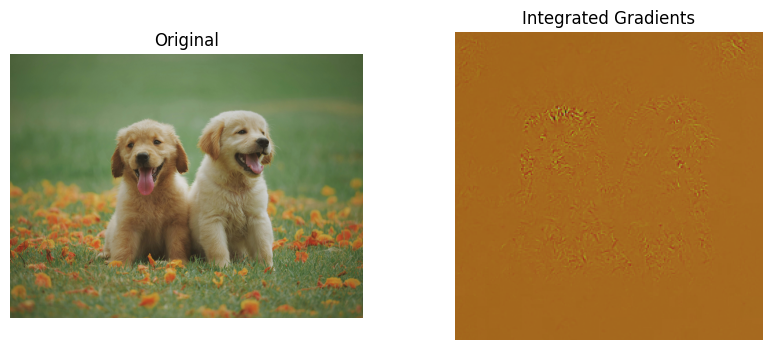

In [11]:
ig = IntegratedGradients(model)

baseline = torch.zeros_like(input_tensor).to(device)

attributions_ig = ig.attribute(
    input_tensor,
    baselines=baseline,
    target=target,
    n_steps=50
)

attr_ig = attributions_ig.squeeze().detach().cpu().numpy()
attr_ig = attr_ig.sum(axis=0)
attr_ig_norm = (attr_ig - attr_ig.min()) / (attr_ig.max() - attr_ig.min() + 1e-8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_pil)
plt.imshow(attr_ig_norm, cmap="hot", alpha=0.5)
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()


---

## Guided Backpropagation

### What is Guided Backpropagation?

**Guided Backpropagation** is a gradient-based visualization technique that produces sharp, detailed saliency maps for a model’s prediction.

It modifies the **backward pass** of ReLU activations so that only **positive gradients** passing through **positive activations** are allowed to flow back. This “guides” the backpropagation process and removes noisy, negative gradients.

> Intuition:  
> *“Highlight only those input pixels that positively and strongly support the activation of neurons leading to the target class.”*

---

### How is it different from plain gradients?

For a standard network:

- Forward:  
  \[
  $\text{ReLU}(z) = \max(0, z)$
  \]
- Backward (standard):  
  Gradients are passed back whenever the **forward activation** is positive.

In **Guided Backprop**:

- Forward: same as ReLU:
  \[
  $\text{ReLU}(z) = \max(0, z)$
  \]
- Backward (modified rule):  
  Gradients are passed back **only if**:
  - The forward activation is positive, **and**
  - The backward gradient is also positive.

So, negative gradients are zeroed out during backpropagation through ReLUs.

This leads to:

- Saliency maps that are **sharper** and more **edge-focused** than raw gradients.  
- Visualizations that look like “edge drawings” of the object the network cares about.

---

### Intuition

- Plain gradient saliency maps can be **noisy and diffuse**: they highlight many pixels that might not be clearly related to the object.
- Guided Backprop acts like a **filter**, enforcing:
  - Only *positively contributing* signals are propagated backward.
  - Only neurons that were *active* in the forward pass can carry gradients.

As a result, the final saliency map tends to:

- Highlight **fine-grained structures** (edges, contours).
- Produce visually pleasing explanations.

However:

- Guided Backprop is **not class-discriminative** by itself (it shows what activates the network, not necessarily what distinguishes one class from another).
- It is often combined with other methods, e.g., Guided Grad-CAM.

---

### Pros and Cons

**Pros:**
- Produces **high-resolution, detailed** saliency maps.  
- Easy to implement as a modification of the backprop rules.  
- Good for getting a sense of *where* strong activations originate in the input.

**Cons:**
- Not inherently **class-specific**; it reflects general sensitivity.  
- Depends heavily on ReLU-like nonlinearities (less straightforward for other activations).  
- Still a gradient-based method, so it can be sensitive to small changes and noise.

---

### In this notebook

We will:

1. Take our pretrained **ResNet-50**.  
2. Use **Captum’s `GuidedBackprop`** implementation.  
3. Compute guided backprop attributions for the predicted class.  
4. Aggregate absolute gradients across channels and visualize them as a grayscale saliency map.

This will show a **fine-grained “edge sketch”** of the regions in the image that most strongly influence the model’s output.


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


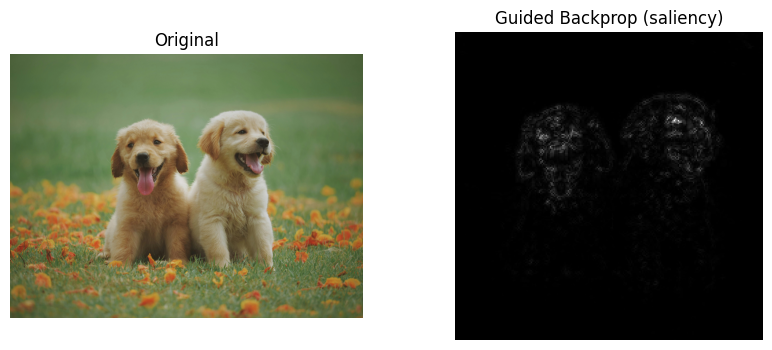

In [12]:
gbp = GuidedBackprop(model)

input_tensor.requires_grad = True

attributions_gbp = gbp.attribute(input_tensor, target=target)
attr_gbp = attributions_gbp.squeeze().detach().cpu().numpy()
# Take absolute values and sum over channels
attr_gbp = np.abs(attr_gbp).sum(axis=0)

attr_gbp_norm = (attr_gbp - attr_gbp.min()) / (attr_gbp.max() - attr_gbp.min() + 1e-8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(attr_gbp_norm, cmap="gray")
plt.title("Guided Backprop (saliency)")
plt.axis("off")
plt.show()


In [13]:
!pip install numpy==2.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
captum 0.8.0 requires numpy<2.0, but you have numpy 2.0.0 which is incompatible.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# LIME for images
from lime import lime_image
from skimage.segmentation import mark_boundaries

# SHAP
import shap

# Grad-CAM family
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Captum for attributions (Integrated Gradients, Occlusion, GuidedBackprop)
from captum.attr import IntegratedGradients, Occlusion, GuidedBackprop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = model.eval().to(device)

# Preprocessing transform for ImageNet models
preprocess = weights.transforms()
imagenet_labels = weights.meta["categories"]

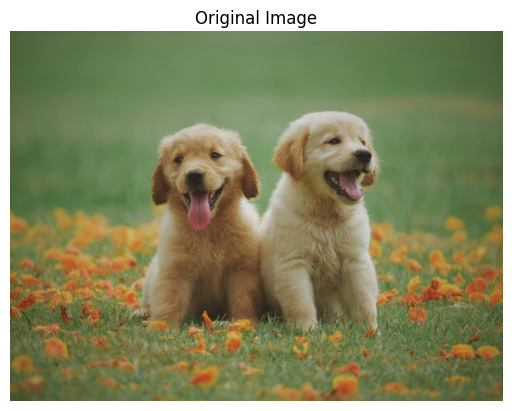

In [3]:
# Example image: a dog (change if you like)
IMAGE_URL = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"

response = requests.get(IMAGE_URL)
img_pil = Image.open(BytesIO(response.content)).convert("RGB")
plt.imshow(img_pil)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [4]:
def prepare_image(img_pil):
    # preprocess returns a tensor [C,H,W], we need [1,C,H,W]
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    return input_tensor

def predict(input_tensor):
    with torch.no_grad():
        logits = model(input_tensor)
        probs = logits.softmax(dim=1)
    return probs, logits

input_tensor = prepare_image(img_pil)
probs, logits = predict(input_tensor)
top_prob, top_idx = probs.max(dim=1)
pred_label = imagenet_labels[top_idx.item()]

print(f"Top prediction: {pred_label} (prob={top_prob.item():.3f})")

Top prediction: golden retriever (prob=0.543)


In [5]:
!pip install shap lime scikit-image grad-cam --quiet

In [6]:
# 1. Prepare input tensor
input_tensor = preprocess(img_pil).unsqueeze(0).to(device)  # [1,3,H,W]

# 2. Get prediction
model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    probs = logits.softmax(dim=1)

top_prob, top_idx = probs.max(dim=1)

# 3. Define target class index and label
target = top_idx.item()                    # this is what Grad-CAM will explain
pred_label = imagenet_labels[target]       # human-readable label

print(f"Top prediction: {pred_label} (class id={target}, prob={top_prob.item():.3f})")

Top prediction: golden retriever (class id=207, prob=0.543)


---

## Grad-CAM (Gradient-weighted Class Activation Mapping)

### What is Grad-CAM?

**Grad-CAM (Gradient-weighted Class Activation Mapping)** is a popular XAI technique for **CNN-based vision models** that produces a **coarse, class-discriminative heatmap** over an input image.

> Intuition:  
> *“Which spatial locations in the last convolutional feature maps are most important for this particular class prediction?”*

Grad-CAM uses:
- The **feature maps** from a chosen convolutional layer, and  
- The **gradients** of the target class score w.r.t. those feature maps  

to compute a **heatmap** that highlights *where* the model is looking for that class.

---

### Why convolutional feature maps?

In a CNN:

- Early layers capture **low-level features** (edges, textures) with high spatial resolution.
- Deeper layers (e.g., last conv block) capture **high-level, semantic features** (object parts) with coarser spatial resolution.

Grad-CAM uses one of these *deep* convolutional layers because:

- Its feature maps still preserve **spatial layout** (where things are in the image).  
- Its channels encode **semantic concepts** relevant to the prediction.

This makes Grad-CAM heatmaps:

- **Localization-friendly** (they show *where* the network is attending).  
- **Class-specific** (different classes get different heatmaps).

---

### How does Grad-CAM work?

Let:
- \( $A^k$ \) be the \(k\)-th feature map (activation map) from the chosen convolutional layer.  
- \( $y^c$ \) be the score for class \( c \) (pre-softmax logit).  
- \( Z \) be the number of spatial locations in \( $A^k$ \) (height X width).

1. **Compute gradients** of the target class score w.r.t. each feature map:
   \[
   $\frac{\partial y^c}{\partial A_{ij}^k}$
   \]

2. **Global average pool** these gradients over spatial dimensions to get a weight for each channel \( k \):
   \[
   $\alpha_k^c = \frac{1}{Z} \sum_{i,j} \frac{\partial y^c}{\partial A_{ij}^k}$
   \]

3. **Form a weighted combination** of feature maps:
   \[
   $L_{\text{Grad-CAM}}^c = \text{ReLU} \left( \sum_k \alpha_k^c A^k \right)$
   \]

4. **Apply ReLU** to keep only those regions that have a *positive influence* on the class score.

5. **Upsample** the resulting coarse heatmap to the input image size and overlay it as a colored mask.

---

### What does the heatmap mean?

- **Bright (red/yellow) regions**: spatial locations that strongly support the target class prediction.  
- **Dark (blue/transparent) regions**: locations that are less important or irrelevant for that class.  

Because it aggregates over channels in a deep conv layer and uses **class-specific gradients**, Grad-CAM is:

- **Class-discriminative** (different classes → different maps).  
- **Localized** (highlights regions, not individual pixels).

---

### Pros and Cons

**Pros:**
- Produces **intuitive, localized heatmaps** that are easy to interpret.  
- Works with many CNN architectures (does *not* require special global average pooling like the original CAM).  
- **Class-specific** explanations.  
- Only needs a **single forward and backward pass**.

**Cons:**
- Heatmaps are **coarse** (limited by the resolution of the chosen conv feature maps).  
- Depends on the choice of **target layer** (different layers can give different maps).  
- Primarily designed for **convolutional networks** (extensions needed for transformers / non-CNN models).

---

### In this notebook

We will:

1. Use a pretrained **ResNet-50** image classifier.  
2. Select the **last convolutional block** (e.g., `model.layer4[-1]`) as the target layer.  
3. Use the **pytorch-grad-cam** library to:
   - Compute Grad-CAM for the predicted class.  
   - Generate a heatmap.  
   - Overlay it on the original image.  

This will show **where** in the image the model “looks” to justify its current prediction.


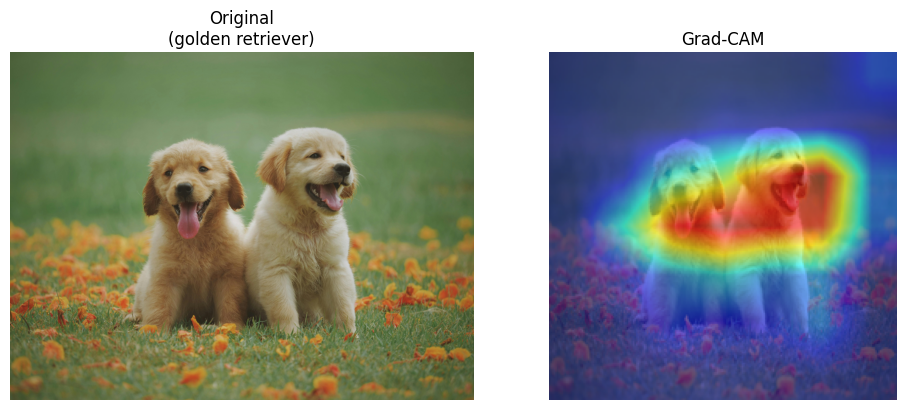

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Make sure model & input are ready
model.eval()
model.to(device)
input_tensor = input_tensor.to(device)   # [1,3,H,W]

# 1. Choose target conv layer (last block of ResNet-50)
target_layers = [model.layer4[-1]]

# 2. Create Grad-CAM object
cam = GradCAM(
    model=model,
    target_layers=target_layers
    # use_cuda=(device.type == "cuda")   # if your version complains, just drop this arg
)

# 3. Target class (top predicted class)
targets = [ClassifierOutputTarget(target)]

# 4. Compute Grad-CAM mask
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # [H_cam, W_cam]

# 5. Resize the original image to the same size as the mask
H_cam, W_cam = grayscale_cam.shape
img_resized = img_pil.resize((W_cam, H_cam))  # PIL wants (width, height)

rgb_img = np.array(img_resized).astype(np.float32) / 255.0  # [H_cam, W_cam, 3]

# 6. Overlay heatmap on resized image
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 7. Plot both original and Grad-CAM visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()


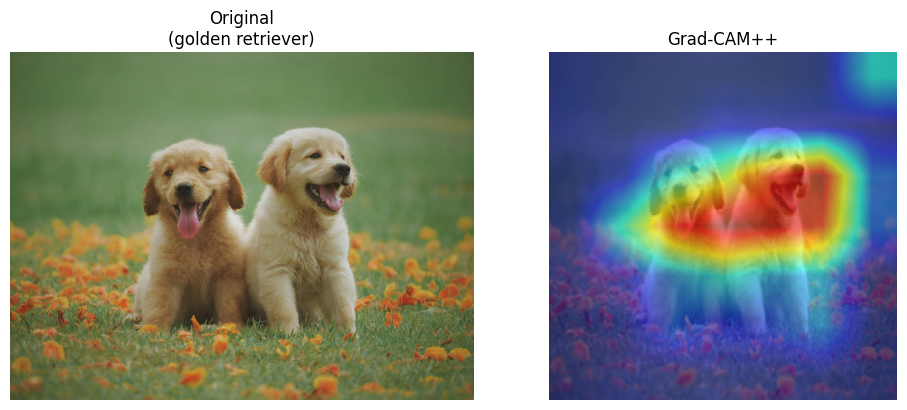

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model.eval()
model.to(device)
input_tensor = input_tensor.to(device)

# 1. Target layer (same as Grad-CAM)
target_layers = [model.layer4[-1]]

# 2. Create Grad-CAM++ object
cam_pp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
    # use_cuda=(device.type == "cuda")  # drop this arg if your version complains
)

# 3. Target class: same 'target' as before
targets = [ClassifierOutputTarget(target)]

# 4. Compute Grad-CAM++ mask
grayscale_cam_pp = cam_pp(input_tensor=input_tensor, targets=targets)[0]  # [H_cam,W_cam]

# 5. Resize original image to mask size
H_cam, W_cam = grayscale_cam_pp.shape
img_resized_pp = img_pil.resize((W_cam, H_cam))

rgb_img_pp = np.array(img_resized_pp).astype(np.float32) / 255.0

# 6. Overlay heatmap
visualization_pp = show_cam_on_image(rgb_img_pp, grayscale_cam_pp, use_rgb=True)

# 7. Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization_pp)
plt.title("Grad-CAM++")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# 1. Function that LIME will use to query the model
def batch_predict(images):
    """
    images: list/array of images as float32 in [0,1], shape (H,W,3)
    returns: numpy array of probabilities [N, num_classes]
    """
    model.eval()
    batch_tensors = []

    for img in images:
        # img is HWC, float [0,1] -> uint8 -> PIL
        pil = Image.fromarray((img * 255).astype(np.uint8))
        t = preprocess(pil)             # [3,224,224]
        batch_tensors.append(t)

    batch = torch.stack(batch_tensors).to(device)  # [N,3,224,224]

    with torch.no_grad():
        logits = model(batch)
        probs = logits.softmax(dim=1)

    return probs.cpu().numpy()


# 2. Prepare the original image for LIME (HWC, float in [0,1])
img_lime = np.array(img_pil).astype(np.float32) / 255.0

# 3. Create the LIME image explainer
explainer = lime_image.LimeImageExplainer()

# This step can take a bit of time (num_samples perturbations)
explanation = explainer.explain_instance(
    img_lime,
    batch_predict,
    top_labels=5,
    hide_color=0,
    num_samples=20
)

# 4. Choose which class to explain (use same 'target' as Grad-CAM)
lime_label = target    # or explanation.top_labels[0]

# Get an image & mask of the important superpixels
temp, mask = explanation.get_image_and_mask(
    lime_label,
    positive_only=True,
    num_features=5,   # number of superpixels to highlight
    hide_rest=False
)

# 5. Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME – important superpixels")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as T

model.eval()
model.to(device)
input_tensor = input_tensor.to(device)   # [1,3,H,W]

# 1. Build a small background dataset (random crops of the same image)
background_images = []
bg_transform = T.Compose([
    T.RandomResizedCrop(size=img_pil.size[0], scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
])

for _ in range(20):          # 20 background samples is enough for a demo
    bg_pil = bg_transform(img_pil)
    bg_tensor = preprocess(bg_pil)       # [3,224,224]
    background_images.append(bg_tensor)

background = torch.stack(background_images).to(device)  # [20,3,224,224]

# 2. Create DeepExplainer
explainer_shap = shap.DeepExplainer(model, background)

# 3. Compute SHAP values for the current image
#    shap_values is a list of length = num_classes (1000 for ImageNet)
shap_values = explainer_shap.shap_values(input_tensor)

# 4. Take SHAP values for the target class
#    shap_values[target]: [1, 3, H, W]
sv = shap_values[target][0]              # [3,H,W]

# Aggregate over color channels (mean)
sv_agg = sv.mean(axis=0)                 # [H,W]
sv_agg = sv_agg.cpu().numpy()

# Normalize to [-1,1] for visualization
max_abs = np.max(np.abs(sv_agg)) + 1e-8
sv_norm = sv_agg / max_abs               # now in [-1,1]

# 5. Resize original image to same size as SHAP map (should already be 224x224)
H_shap, W_shap = sv_norm.shape
img_resized_shap = img_pil.resize((W_shap, H_shap))
rgb_img_shap = np.array(img_resized_shap).astype(np.float32) / 255.0

# 6. Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sv_norm, cmap="bwr")
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("SHAP (raw map)\nred=positive, blue=negative")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rgb_img_shap)
plt.imshow(sv_norm, cmap="bwr", alpha=0.5)
plt.title("SHAP overlay")
plt.axis("off")

plt.tight_layout()
plt.show()
